In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import calinski_harabasz_score, silhouette_score
import pandas as pd

In [24]:
df = pd.read_csv('../data/customers.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


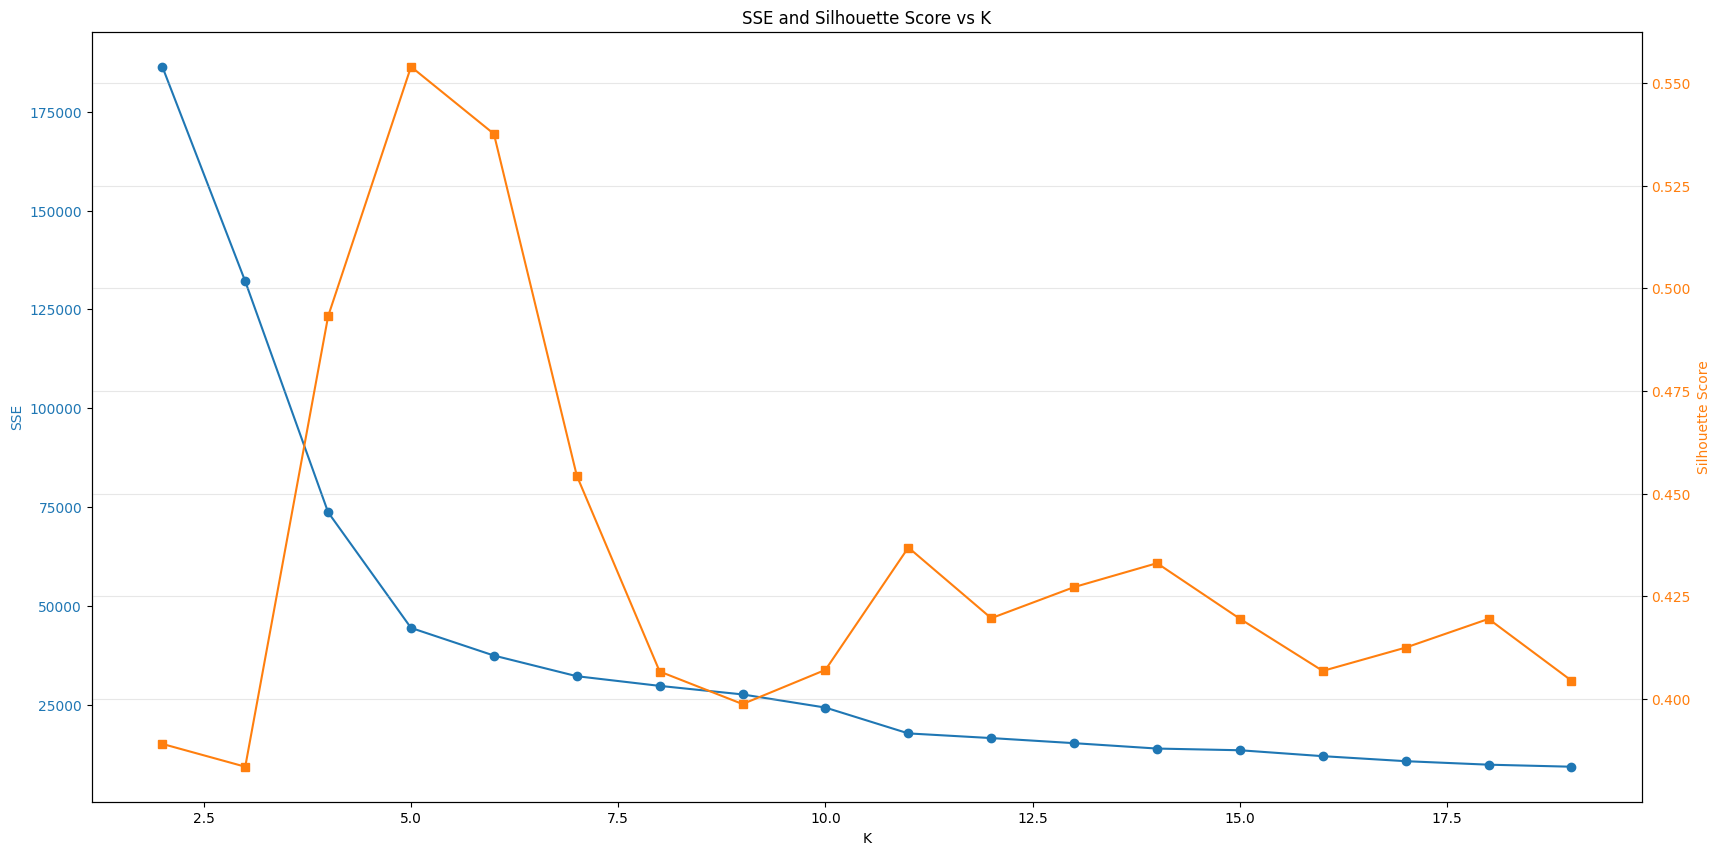

In [25]:
see_lst = []
sc_lst = []

x = df.iloc[:, 3:5]

for k in range(2, 20):
    estimator = KMeans(n_clusters=k, max_iter=100, random_state=23)
    estimator.fit(x)
    see_lst.append(estimator.inertia_)
    sc_lst.append(silhouette_score(x, estimator.labels_))

# plt.figure(figsize=(20, 10))
# plt.plot(range(2, 20), see_lst, label='SSE', marker='o')
# plt.show()

# plt.figure(figsize=(20, 10))
# plt.plot(range(2, 20), sc_lst, label='Silhouette Score', marker='o')
# plt.show()

fig, ax1 = plt.subplots(figsize=(20, 10))
# 左轴：SSE
ax1.plot(range(2, 20), see_lst, color='tab:blue', marker='o', label='SSE')
ax1.set_xlabel('K')
ax1.set_ylabel('SSE', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 右轴：Silhouette
ax2 = ax1.twinx()
ax2.plot(range(2, 20), sc_lst, color='tab:orange', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('SSE and Silhouette Score vs K')
plt.grid(alpha=0.3)
plt.show()

In [26]:
k = 5
estimator = KMeans(n_clusters=k, max_iter=100, random_state=23)  # 肘部法可视化选择 K=5
estimator.fit(x)
y_pred = estimator.predict(x)  # y_pred 是每个样本所属的簇的标签
y_pred


array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

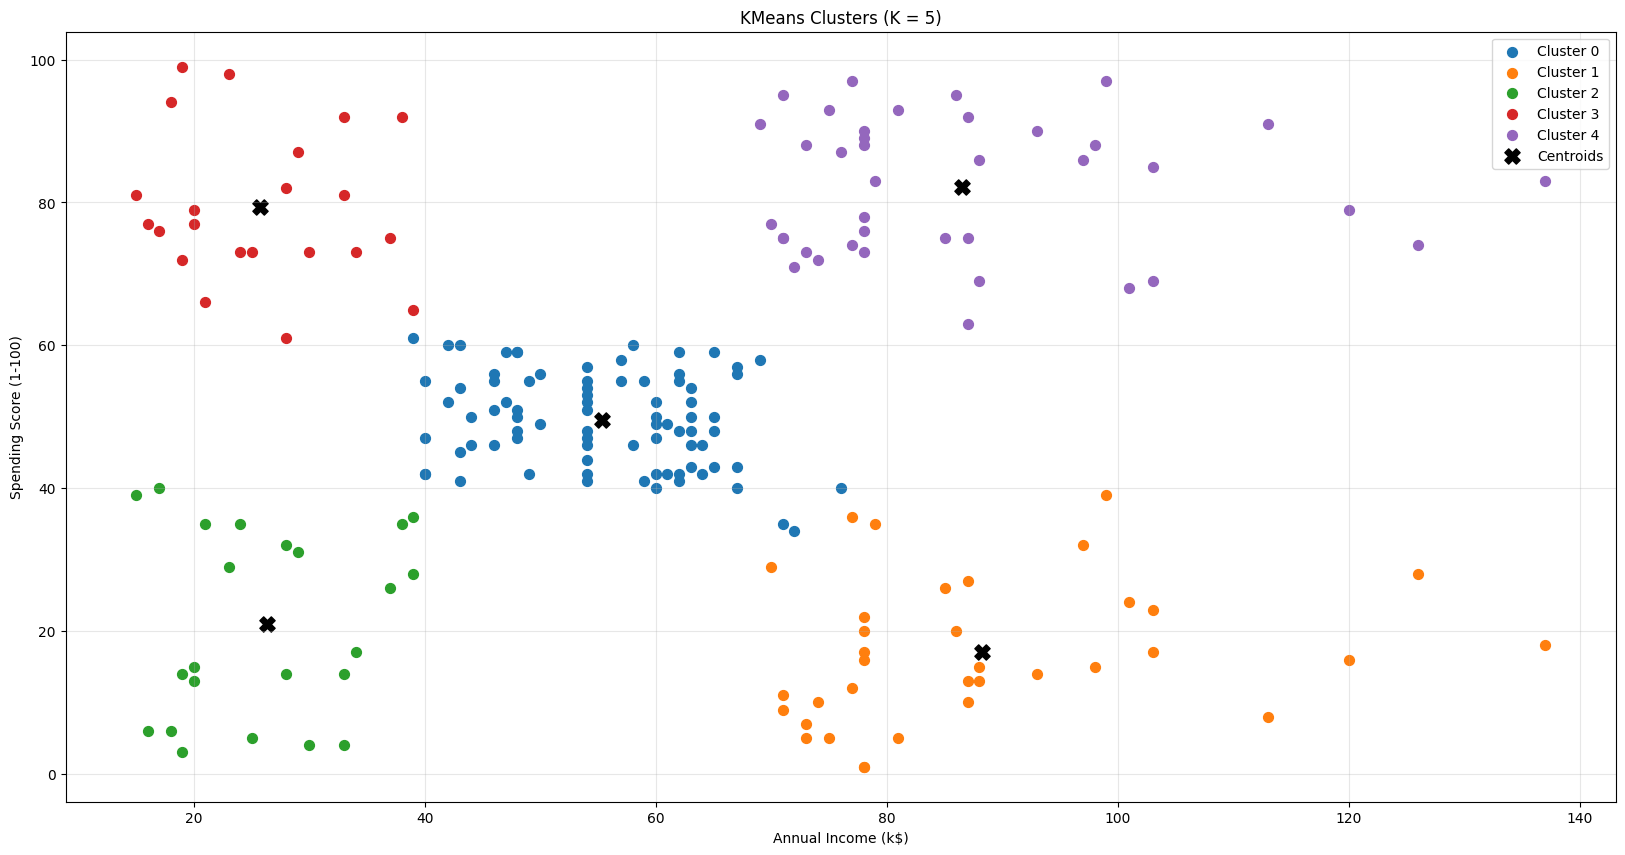

In [29]:
plt.figure(figsize=(20, 10))
for i in range(estimator.n_clusters):
    pos = (y_pred == i)
    plt.scatter(x.values[pos, 0], x.values[pos, 1], label=f'Cluster {i}', s=50)

centers = estimator.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=120, label='Centroids')

plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title(f'KMeans Clusters (K = {k})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()